### Фокин Н. А. 5130901/30201

## Упражнения к главе 6

### Упражнение 6.1

В ходе выполнения данного упражнения было проведено сравнение времени работы analyze1 и analyze2

In [106]:
import thinkdsp
import numpy as np

Функция analyze1 ($O(n^3)$):

In [107]:
def analyze1(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(np.pi * 2 * args)
    amps = np.linalg.solve(M, ys)
    return amps

Функция analyze2 ($O(n^2)$):

In [108]:
def analyze2(ys, fs, ts):
    args = np.outer(ts, fs)
    M = np.cos(np.pi * 2 * args)
    amps = np.dot(M, ys) / 2
    return amps

Функция для тестирования скорости:

In [109]:
import timeit
def speedTest(ns, func):
    results = []
    for N in ns:
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        noise = thinkdsp.UncorrelatedGaussianNoise()
        wave = noise.make_wave(duration=1.0, framerate=11025)
        ys = wave.ys[:N]
        result = timeit.timeit(lambda: func(ys, freqs, ts), number=1)
        results.append(result)
        print(f"N={N}: {result:.6f} сек")
    
    return results

Функция для построения графиков:

In [110]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

def plotBest(ns, bests, label):
    plt.plot(ns, bests, label=label)
    plt.xscale('log')
    plt.yscale('log')
    
    x = np.log(ns)
    y = np.log(bests)
    slope = linregress(x, y)[0]
    
    print(f"Наклон для {label}: {slope:.3f}")
    return slope

Запустим тесты и проанализируем их результаты. Для первой функции:

N=64: 0.000298 сек
N=128: 0.000687 сек
N=256: 0.003331 сек
N=512: 0.016099 сек
N=1024: 0.089690 сек
Наклон для analyze1: 2.102


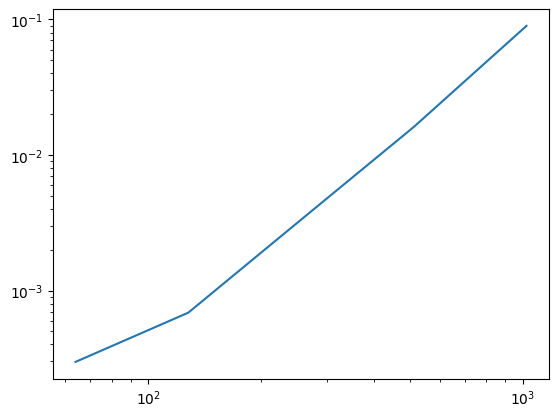

In [111]:
ns = 2 ** np.arange(6, 11)


bests1 = speedTest(ns, analyze1)
slope1 = plotBest(ns, bests1, 'analyze1')

И для второй:

N=64: 0.000119 сек
N=128: 0.000330 сек
N=256: 0.000719 сек
N=512: 0.004473 сек
N=1024: 0.019446 сек
Наклон для analyze2: 1.846


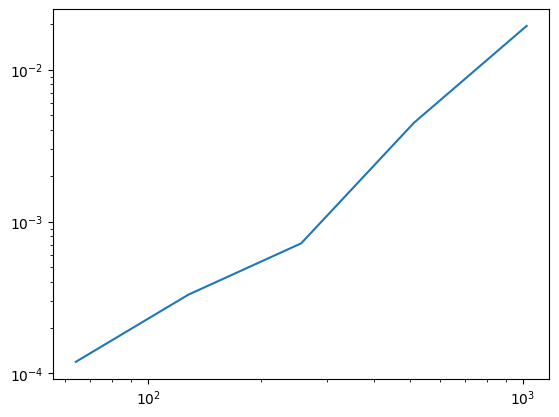

In [112]:
bests2 = speedTest(ns, analyze2)
slope2 = plotBest(ns, bests2, 'analyze2')

Также протестируем scipy.fftpack.dct:

N=64: 0.000104 сек
N=128: 0.000036 сек
N=256: 0.000025 сек
N=512: 0.000032 сек
N=1024: 0.000029 сек
Наклон для scipy_dct: -0.382


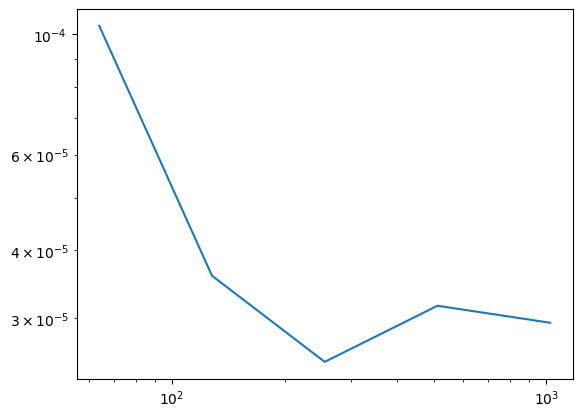

In [113]:
import scipy.fftpack

def scipy_dct(ys, freqs, ts):
    return scipy.fftpack.dct(ys, type=3)

bests3 = speedTest(ns, scipy_dct)
slope3 = plotBest(ns, bests3, 'scipy_dct')

И dct_iv:

N=64: 0.000102 сек
N=128: 0.000203 сек
N=256: 0.000805 сек
N=512: 0.003838 сек
N=1024: 0.012996 сек
Наклон для dct_iv: 1.824


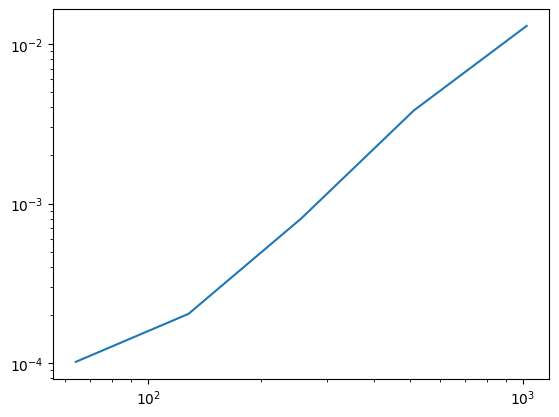

In [114]:
def dct_iv(ys, freqs, ts):
    args = np.outer(ts, freqs)
    M = np.cos(2 * np.pi * args)
    amps = np.dot(M, ys)/2
    return amps

bests4 = speedTest(ns, dct_iv)
slope4 = plotBest(ns, bests4, 'dct_iv')

Выведем сравнительный график:

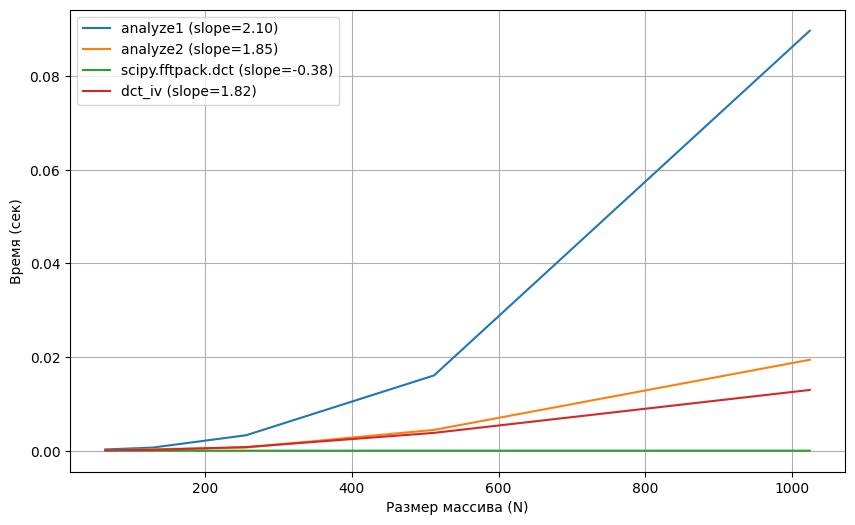

In [115]:
plt.figure(figsize=(10, 6))
plt.plot(ns, bests1, label='analyze1 (slope=%.2f)' % slope1)
plt.plot(ns, bests2, label='analyze2 (slope=%.2f)' % slope2)
plt.plot(ns, bests3, label='scipy.fftpack.dct (slope=%.2f)' % slope3)
plt.plot(ns, bests4, label='dct_iv (slope=%.2f)' % slope4)
plt.xlabel('Размер массива (N)')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

Таким образом, scipy.fftpack.dct - наиболее эффективная реализация. Время выполнения практически не зависит от размера массива и остаётся на уровне ~0.001 секунд; analyze2 и dct_iv  показывают близкие результаты с приблизительно линейной зависимостью времени от размера данных; analyze1 - наименее эффективная из тестируемых реализаций. Время выполнения растёт быстрее остальных и достигает 0.07 сек при N=1000.

### Упражнение 6.2

В ходе данного упражнения была реализована версия алгороитма сжатия звука с помощью ДКП.

In [116]:
wave = thinkdsp.read_wave('100475__iluppai__saxophone-weep.wav')

Функция сжатия (удаление малых амплитуд):

In [117]:
def compress(dct, thresh=0.1):
    count = 0
    total = len(dct.amps)
    
    for i, amp in enumerate(dct.amps):
        if np.abs(amp) < thresh:
            dct.hs[i] = 0
            count += 1
    
    percent = 100 * count / total
    print(f"Удалено: {count}/{total} ({percent:.2f}%)")
    return percent

Выделим короткий сегмент:

In [118]:
segment = wave.segment(start=1.2, duration=0.5)
segment.normalize()
seg_dct = segment.make_dct()

Произведем его сжатие с разными порогами:

In [119]:
for thresh in [0.01, 0.1, 0.5, 1.0, 2.0]:
    print(f"\nПорог = {thresh}:")
    seg_dct_copy = segment.make_dct()
    compress(seg_dct_copy, thresh=thresh)
    seg_compressed = seg_dct_copy.make_wave()


Порог = 0.01:
Удалено: 480/22050 (2.18%)

Порог = 0.1:
Удалено: 4511/22050 (20.46%)

Порог = 0.5:
Удалено: 12908/22050 (58.54%)

Порог = 1.0:
Удалено: 15296/22050 (69.37%)

Порог = 2.0:
Удалено: 17310/22050 (78.50%)


Теперь произведем сжатие всего сигнала. Для этого используем следующую функцию:

In [120]:
def make_dct_spectrogram(wave, seg_length=1024):
    window = np.hamming(seg_length)
    i, j = 0, seg_length
    step = seg_length // 2
    
    spec_map = {}
    
    while j < len(wave.ys):
        segment = wave.slice(i, j)
        segment.window(window)
        
        t = (segment.start + segment.end) / 2
        spec_map[t] = segment.make_dct()
        
        i += step
        j += step
    
    return thinkdsp.Spectrogram(spec_map, seg_length)

In [121]:
spectro = make_dct_spectrogram(wave, seg_length=1024)
len(spectro.spec_map)

1010

Применим сжатие к каждому из сегментов:

In [ ]:
total_compression = []
for t, dct in sorted(spectro.spec_map.items()):
    percent = compress(dct, thresh=0.2)
    total_compression.append(percent)

Удалено: 1018/1024 (99.41%)
Удалено: 1016/1024 (99.22%)
Удалено: 1014/1024 (99.02%)
Удалено: 1017/1024 (99.32%)
Удалено: 1016/1024 (99.22%)
Удалено: 1017/1024 (99.32%)
Удалено: 1016/1024 (99.22%)
Удалено: 1020/1024 (99.61%)
Удалено: 1014/1024 (99.02%)
Удалено: 1005/1024 (98.14%)
Удалено: 1009/1024 (98.54%)
Удалено: 1015/1024 (99.12%)
Удалено: 1015/1024 (99.12%)
Удалено: 1016/1024 (99.22%)
Удалено: 1016/1024 (99.22%)
Удалено: 1015/1024 (99.12%)
Удалено: 1017/1024 (99.32%)
Удалено: 1020/1024 (99.61%)
Удалено: 1013/1024 (98.93%)
Удалено: 1017/1024 (99.32%)
Удалено: 1013/1024 (98.93%)
Удалено: 1017/1024 (99.32%)
Удалено: 1018/1024 (99.41%)
Удалено: 1015/1024 (99.12%)
Удалено: 1013/1024 (98.93%)
Удалено: 794/1024 (77.54%)
Удалено: 785/1024 (76.66%)
Удалено: 955/1024 (93.26%)
Удалено: 995/1024 (97.17%)
Удалено: 992/1024 (96.88%)
Удалено: 976/1024 (95.31%)
Удалено: 925/1024 (90.33%)
Удалено: 802/1024 (78.32%)
Удалено: 836/1024 (81.64%)
Удалено: 850/1024 (83.01%)
Удалено: 882/1024 (86.13%)
Уда

In [123]:
print(f"\nСредняя степень сжатия: {np.mean(total_compression):.2f}%")
print(f"Минимальная: {np.min(total_compression):.2f}%")
print(f"Максимальная: {np.max(total_compression):.2f}%")


Средняя степень сжатия: 82.15%
Минимальная: 65.92%
Максимальная: 99.61%


Восстановим сжатый сигнал:

In [124]:
wave_compressed = spectro.make_wave()

Изначальная запись:

In [125]:
wave.make_audio()

Сжатая запись:

In [126]:
wave_compressed.make_audio()

Таким образом, в сжатой аудиозаписи появляется явно заметный шум, который ложится поверх звука саксофона. Найдем порог, при котором разница между записями становится заметной:

In [129]:
test_thresholds = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
waves = {}

for thresh in test_thresholds:
    print(f"\nПорог: {thresh}")
    spectro_test = make_dct_spectrogram(wave.segment(duration=2.0), seg_length=1024)
    
    for t, dct in spectro_test.spec_map.items():
        compress(dct, thresh=thresh)
    
    wave_test = spectro_test.make_wave()
    waves[thresh] = wave_test.make_audio()


Порог: 0.01
Удалено: 276/1024 (26.95%)
Удалено: 280/1024 (27.34%)
Удалено: 275/1024 (26.86%)
Удалено: 283/1024 (27.64%)
Удалено: 262/1024 (25.59%)
Удалено: 246/1024 (24.02%)
Удалено: 268/1024 (26.17%)
Удалено: 273/1024 (26.66%)
Удалено: 263/1024 (25.68%)
Удалено: 249/1024 (24.32%)
Удалено: 263/1024 (25.68%)
Удалено: 274/1024 (26.76%)
Удалено: 277/1024 (27.05%)
Удалено: 293/1024 (28.61%)
Удалено: 266/1024 (25.98%)
Удалено: 263/1024 (25.68%)
Удалено: 259/1024 (25.29%)
Удалено: 307/1024 (29.98%)
Удалено: 253/1024 (24.71%)
Удалено: 274/1024 (26.76%)
Удалено: 276/1024 (26.95%)
Удалено: 263/1024 (25.68%)
Удалено: 287/1024 (28.03%)
Удалено: 254/1024 (24.80%)
Удалено: 218/1024 (21.29%)
Удалено: 180/1024 (17.58%)
Удалено: 163/1024 (15.92%)
Удалено: 206/1024 (20.12%)
Удалено: 226/1024 (22.07%)
Удалено: 227/1024 (22.17%)
Удалено: 215/1024 (21.00%)
Удалено: 203/1024 (19.82%)
Удалено: 172/1024 (16.80%)
Удалено: 183/1024 (17.87%)
Удалено: 168/1024 (16.41%)
Удалено: 209/1024 (20.41%)
Удалено: 203/10

In [136]:
waves[0.01]

In [137]:
waves[0.05]

In [ ]:
waves[0.1]

In [140]:
waves[0.2]

In [139]:
waves[1]

Таким образом, уже при пороге в 0.05 отчетливо заметны искажения

### Упражнение 6.3

В ходе выполнения данного упражнения было исследовано влияние фазы на восприятие звука. Выберем полусекундный сегмент треугольного сигнала:

In [142]:
signal = thinkdsp.TriangleSignal(freq=500, offset=0)
wave = signal.make_wave(duration=0.5, framerate=40000)
wave.make_audio()

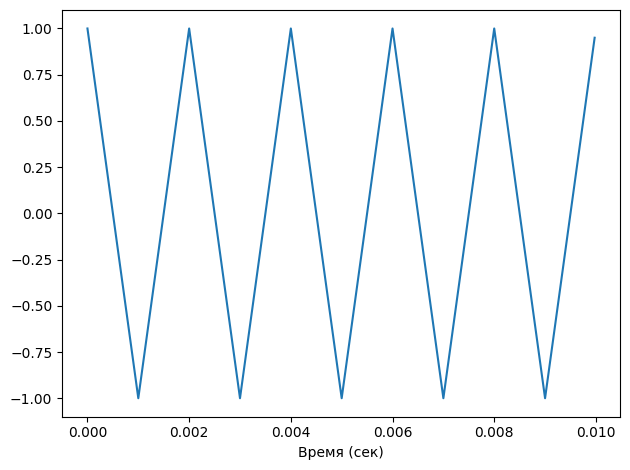

In [143]:
wave.segment(duration=0.01).plot()
thinkdsp.decorate(xlabel='Время (сек)')

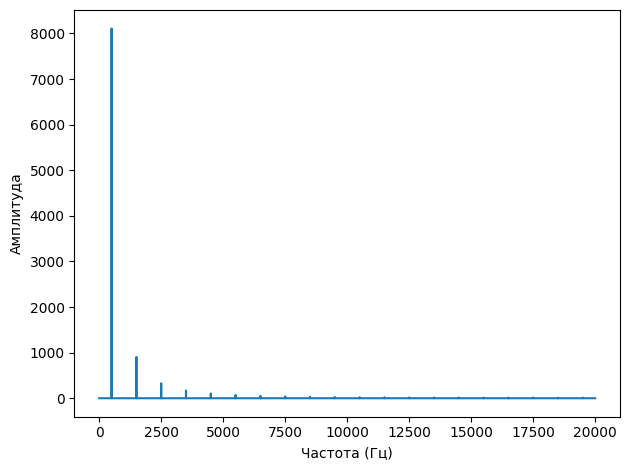

In [144]:
spectrum = wave.make_spectrum()
spectrum.plot()
thinkdsp.decorate(xlabel='Частота (Гц)',
         ylabel='Амплитуда')

Следующая функция строит график угловой части спектра:

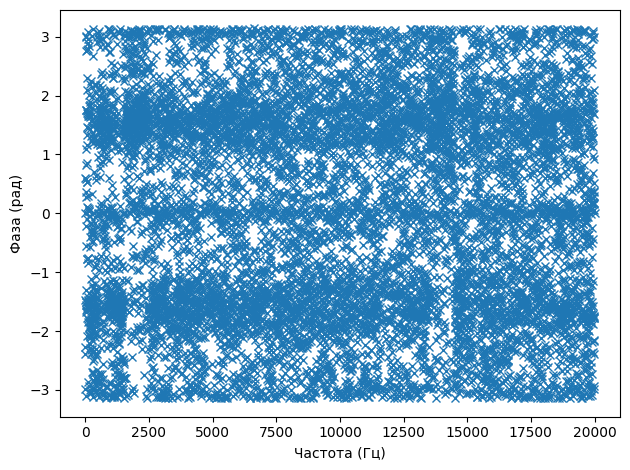

In [146]:
def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = np.nan
    plt.plot(spectrum.fs, angles, 'x')
    thinkdsp.decorate(xlabel='Частота (Гц)', 
             ylabel='Фаза (рад)')


plot_angle(spectrum, thresh=0)

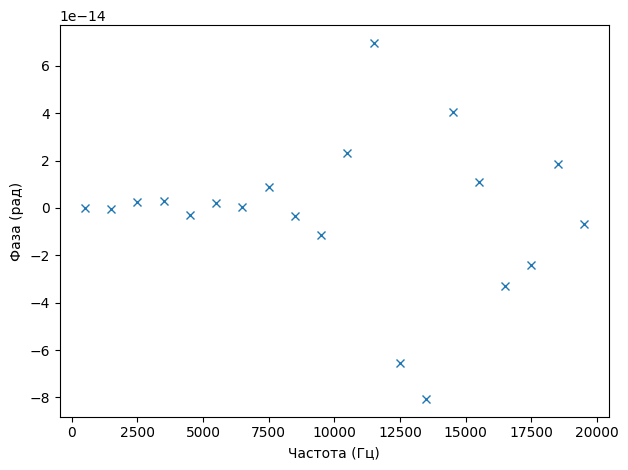

In [151]:
plot_angle(spectrum, thresh=1)

Функция, строящая графики амплитуд, углов и формы волны для заданного спектра:

In [152]:
def plot_three(spectrum, thresh=1):
    plt.figure(figsize=(10, 4))
    plt.subplot(1,3,1)
    spectrum.plot()
    plt.subplot(1,3,2)
    plot_angle(spectrum, thresh=thresh)
    plt.subplot(1,3,3)
    wave = spectrum.make_wave()
    wave.unbias()
    wave.normalize()
    wave.segment(duration=0.01).plot()
    display(wave.make_audio())

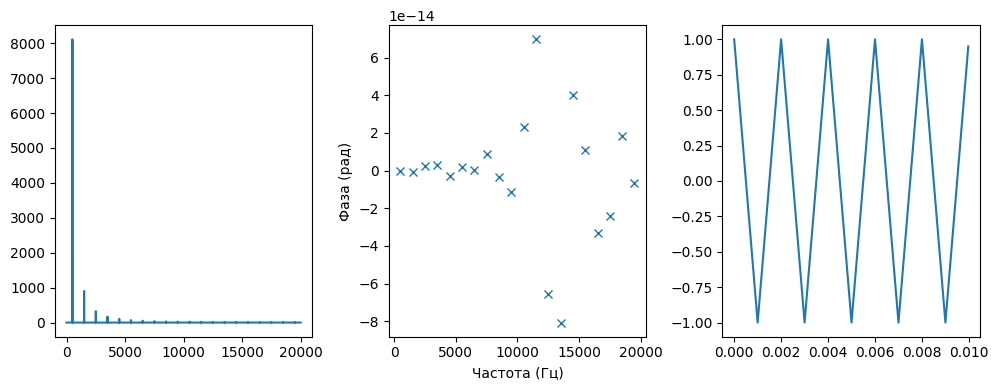

In [153]:
plot_three(spectrum)

Зададим нулевое значение сдвига:

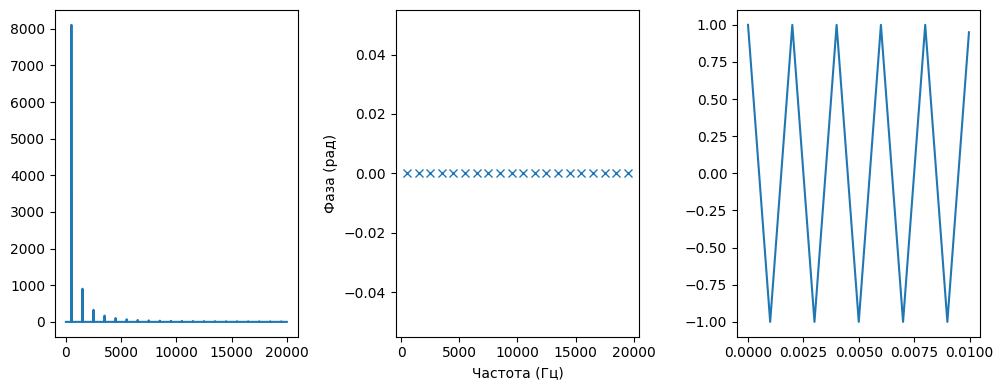

In [155]:
def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res

spectrum2 = zero_angle(spectrum)
plot_three(spectrum2)

Таким образом, для треугольного сигнала заметно изменился только график зависимости фазы от частоты. На слух сигнал не отличим от исходного

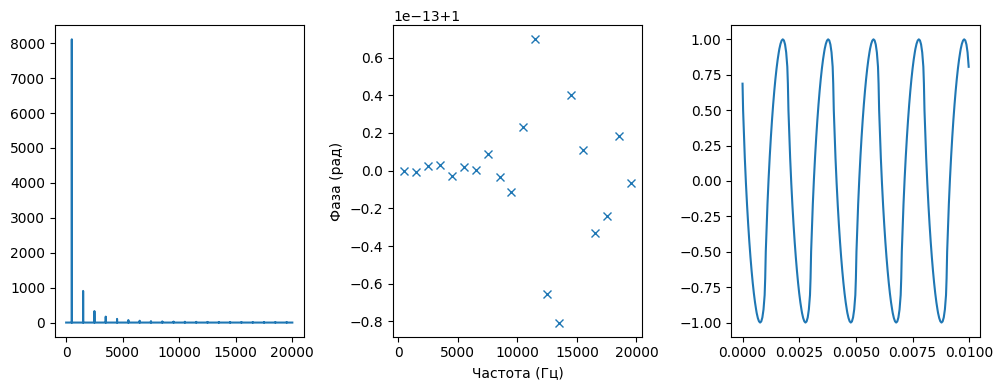

In [157]:
def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= np.exp(1j * offset)
    return res

spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3)

При умножении комплексных компнент на $exp(i φ)$ полчим явное изменение формы волны (крайний правй график), но при этом на слух сигнал также кажется неизменным.

Присвоим углам случайные значения:

In [158]:
def random_angle(spectrum):
    res = spectrum.copy()
    angles = np.random.uniform(0, np.pi * 2, len(spectrum))
    res.hs *= np.exp(1j * angles)
    return res

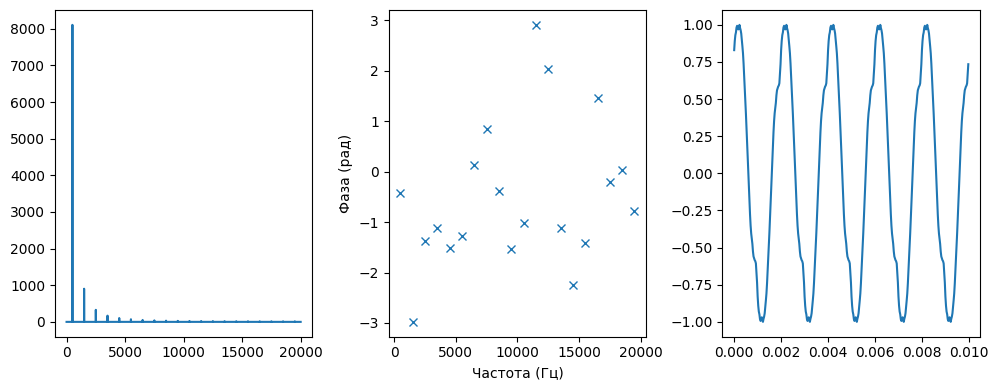

In [159]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4)

Теперь явно заметны изменения в форме волны и зависимости фазы от частоты, но при проигрывании аудиозапись все равно кажется такой же.

Посмотрим на примере той же аудиозаписи саксофона влияние фазы на восприятие звука.

In [ ]:
wave = thinkdsp.read_wave('100475__iluppai__saxophone-weep.wav')
wave.make_audio()

Выберем сегмент с постоянной тональностью:

In [166]:
segment = wave.segment(start=4, duration=0.7)
segment.make_audio()

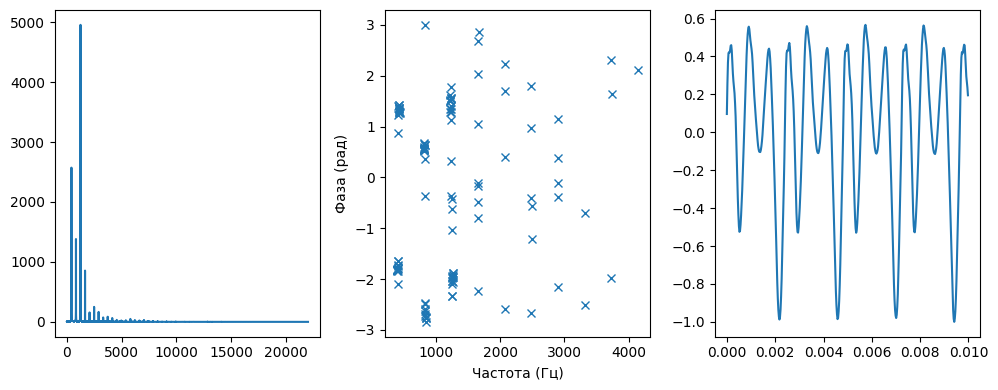

In [167]:
spectrum = segment.make_spectrum()
plot_three(spectrum, thresh=50)

Фаза = 0:

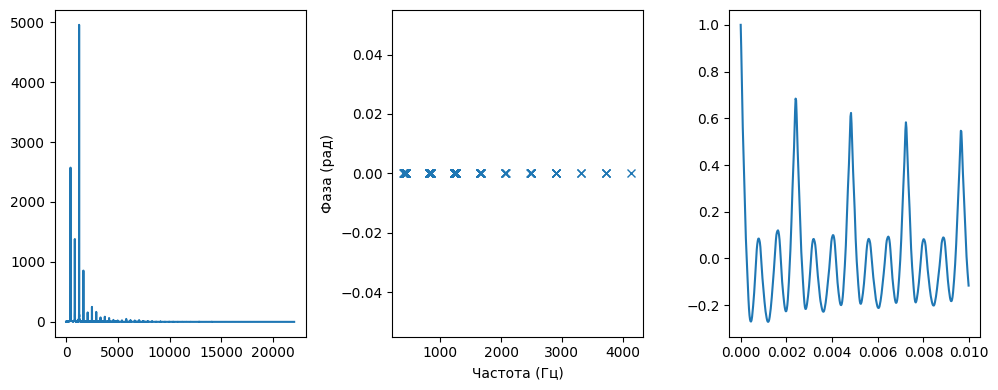

In [168]:
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

Заметно, что в начале сегмента звук тише исходного, но к его концу громкость заметно увеличивается

Сдвинем фазу на 1 рад:

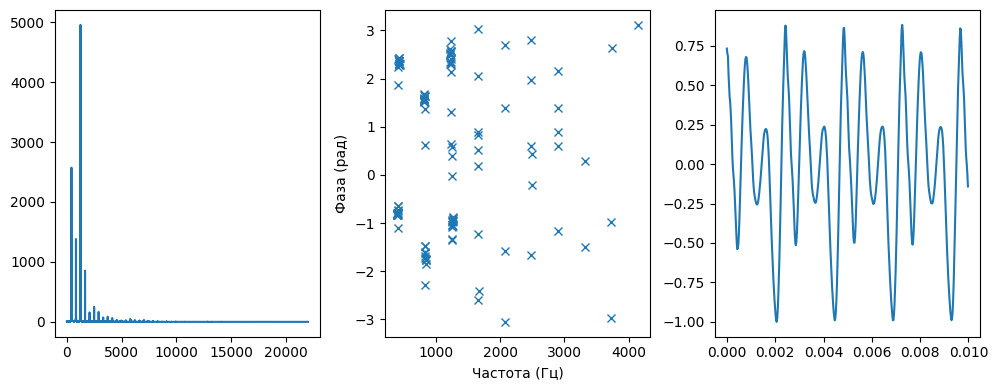

In [169]:
spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3, thresh=50)

Заметных изменений в восприятии звука не появилось. Зададим случайные значения:

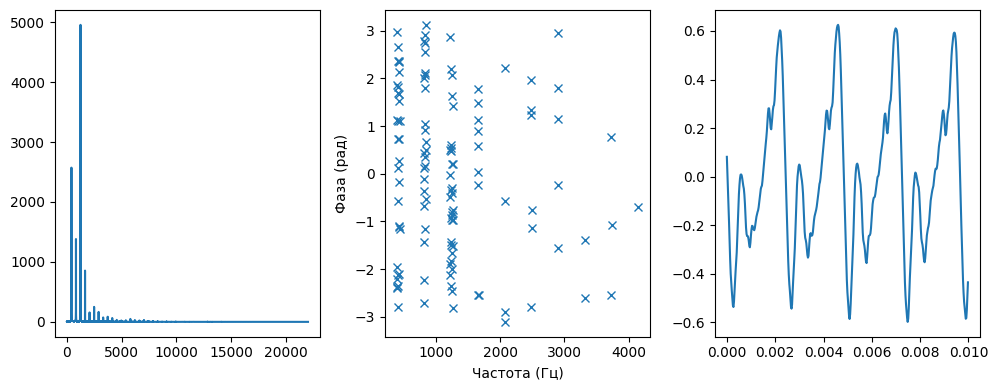

In [170]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

Таким образом, случайное изменение углов придает звуку приглушенный, "дышащий" оттенок.